# Some Theory and Application of Brownian Motion
### by Patrick Salim
#### May 2026

## Section 1: Standard Brownian Motion
We shall make use of concepts from basic probability theory and real analysis to construct a standard Brownian motion without drift. A Brownian Motion is a martingale, which is a stochastic process adapted to a filtration, wherein the conditional expectation of the stochastic process at a later time given the information at an earlier time is exactly the same as the expectation at that earlier time, i.e., the expectation is always the same. Colloquially, this is a "fair game".

**Definition 1.** Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space. Suppose for each $\omega \in \Omega$, there exists continuous functions $W(t)$ for some nonnegative $t$ that satisfies $W(0)=0$, that depends on $\omega$, and that each $W(t)$ is adapted to filtration $\mathcal{F}(t)$. Then $W(t)$ is a Brownian motion, if it has the following properties:
1. For partitions $0=t_0<t_1<...<t_m$, the increments $W(t_n)-W(t_{n-1})$ for all $n \in \{1,2,...,m\}$ are independent and,
2. Each of these increments is normally distributed with expectation zero and variance equal to $d(t_{n-1},t_n)$, where $d(.,.)$ is the metric distance norm.

Indeed, this implies the increments are $i.i.d.$, if the length of each disjoint increment is equal.

We can now construct a Brownian motion by writing a recursive relation $W(t_{n+1})=W(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$, where every $X_{n}$ is a normally distributed sample with mean zero and variance one. This ensures that the expectation of an increment is always zero and that its variance is always its length.

To apply this to code, we make use of the NumPy library to generate $k$ paths. We start by sampling $k \times N$ draws, where $N$ is the time steps, from a standard normal distribution. In addition to this, we shall also import Matplotlib, Pandas, SciPy, and Seaborn.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import norm
import yfinance as yf

# First, we define a random number generator via NumPy.
rng = np.random.default_rng(42)

We shall write a function that plots standard Brownian motion.

In [2]:
def plot_std_brownian(paths, points):
    """
    Simulates paths of standard Brownian motion.

    Parameters
    ----------
    paths: int
        Number of paths.
    points: int
        Number of points for every path.
    """

    # We shall assume no drift (mu=0) and variance one.
    mu, sigma = 0.0, 1.0

    # We shall now utilise the random number generator for the normally distributed sample X.
    X = rng.normal(mu, sigma, (paths, points-1))

    # For the purpose of this project we shall choose $t_m=1$, and for the increments to be of equal length.
    interval = [0.0, 1.0]
    dt = (interval[1] - interval[0]) / (points - 1)
    t_axis = np.linspace(interval[0], interval[1], points)
    W = np.zeros((paths, points))

    # Recursive relation
    increments = X * np.sqrt(dt)
    W[:, 1:] = np.cumsum(increments[:, :points-1], axis=1)

    # Now to plot the standard Brownian motion.
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    for path in range(paths):
        ax.plot(t_axis, W[path, :])
    ax.set_title("Standard Brownian motion")
    ax.set_xlabel("Time")
    ax.set_ylabel("Asset Value")
    plt.show()

    # Kernel Density Estimate at final Time=1
    # We first create a Pandas DataFrame of the sample path values at Time = 1.0.
    final_values = pd.DataFrame({'final_values': W[:, -1]})
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    sns.kdeplot(data=final_values, x='final_values', fill=True, ax=ax)
    ax.set_title("Kernel density estimate of the asset price at Time = 1.0")
    ax.set_xlabel('Asset price at Time = 1.0')
    plt.show()

    # Sample mean and standard deviation of sample at Time=1
    print(final_values.mean(), final_values.std())

By the Strong Law of Large Numbers (Kolmogorov's Law), the sample mean $\bar{W}(t)$ shall converge almost surely to the expectation (in this case, zero) as t goes to infinity. That is, $\mathbb{P}\{\omega \in \Omega \mid \bar{W}(t) \nrightarrow 0\}=0$. This is why the bulk of the paths are denser around the asset value of zero even at Time = 1.0, as per the usual behaviour of standard Brownian motion with no drift.

Indeed, by the Central Limit Theorem, the distribution of the sample shall approach normal distribution. We may see this by using Kernel Density Estimate (KDE) from Seaborn.

We may now specify the quantity of paths and time steps per path, which for the purpose of this project shall be 50 and 1000, respectively, for this example.

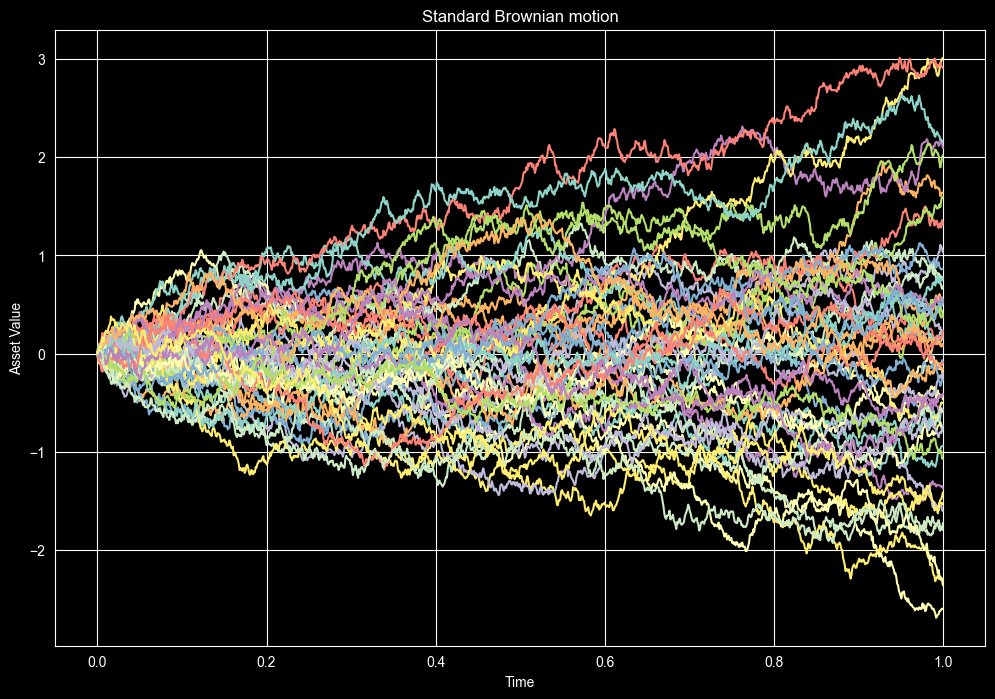

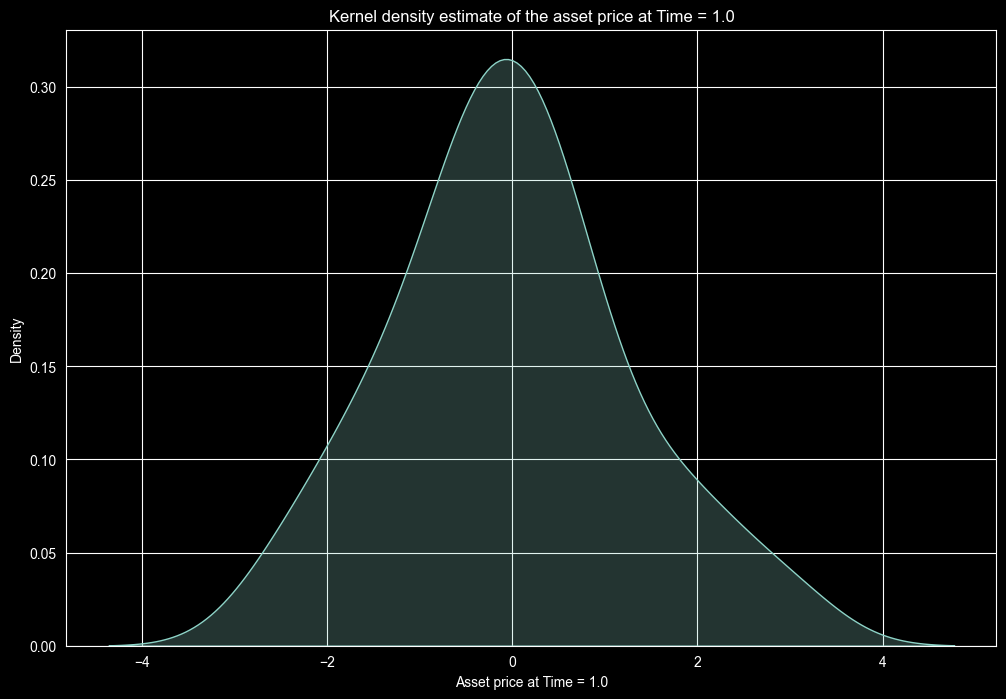

final_values   -0.019448
dtype: float64 final_values    1.282612
dtype: float64


In [3]:
plot_std_brownian(paths=50, points=1000)

This approaches standard normal distribution, as indicated by the sample mean and volatility (standard deviation).

## Section 2: Brownian Motion with Drift and in 3D
Now we shall concern ourselves with standard Brownian motion with constant drift and volatility, call this $Y(t)$. To do this, we shall write $Y(t_{n+1})=Y(t_n)+\mu(t_{n+1}-t_n)+\sigma X_{n+1}\sqrt{t_{n+1}-t_n}$, where again every $X_{n}$ is a normally distributed sample with mean zero and variance one, $\mu$ is the constant drift, and $\sigma$ is the volatility. Again, we shall choose the increments $Y(t_n)-Y(t_{n-1})$ for all $n \in \{1,2,...,m\}$ to be of equal length so that they are $i.i.d.$

Just to show that this recursive relation satisfies the definition of Brownian motion, if we take expectation of any increment, then $\mathbb{E}[Y(t_{n+1})-Y(t_n)]=\mu d(t_n,t_{n+1})$. And, if we take the second moment of this, we shall obtain $\mathbb{E}[(Y(t_{n+1})-Y(t_n))^2]=\mu^2 [d(t_n,t_{n+1})]^2 + \sigma^2 d(t_n,t_{n+1})$. Hence, if we subtract from the second moment $\mathbb{E}[Y(t_{n+1})-Y(t_n)]^2=\mu^2 [d(t_n,t_{n+1})]^2$, then we shall get the variance $\mathrm{Var}[Y(t_{n+1})-Y(t_n)]=\sigma^2 d(t_n,t_{n+1})$.

In [4]:
def plot_drift_brownian(paths, points, drift, volatility):
    """
    Simulates paths of Brownian motion with drift and volatility.

    Parameters
    ----------
    paths: int
        Number of paths.
    points: int
        Number of points for every path.
    drift: float
        The drift rate at each path.
    volatility: float
        The volatility at each path.
    """

    # The normally distributed sample X.
    mu, sigma = 0.0, 1.0
    X = rng.normal(mu, sigma, (paths, points-1))

    # For the purpose of this project we shall choose $t_m=1$, and for the increments to be of equal length.
    interval = [0.0, 1.0]
    dt = (interval[1] - interval[0]) / (points - 1)
    t_axis = np.linspace(interval[0], interval[1], points)
    Y = np.zeros((paths, points))

    # Recursive relation
    increments = drift * dt + volatility * X * np.sqrt(dt)
    Y[:, 1:] = np.cumsum(increments[:, :points-1], axis=1)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    for path in range(paths):
        ax.plot(t_axis, Y[path, :])
    ax.set_title("Brownian motion with constant drift and volatility")
    ax.set_xlabel("Time")
    ax.set_ylabel("Asset Value")
    plt.show()

    # KDE at final Time=1
    final_values_drift = pd.DataFrame({'final_values_drift': Y[:, -1]})
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    sns.kdeplot(data=final_values_drift, x='final_values_drift', fill=True, ax=ax)
    ax.set_title("Kernel density estimate of sample with drift at Time = 1.0")
    ax.set_xlabel('Asset price at Time = 1.0')
    plt.show()

    # Drift and volatility of sample at Time=1
    print(final_values_drift.mean(), final_values_drift.std())

For the purpose of this project, we shall choose the drift to be 4 and volatility to be 3. We now plot the simulation.

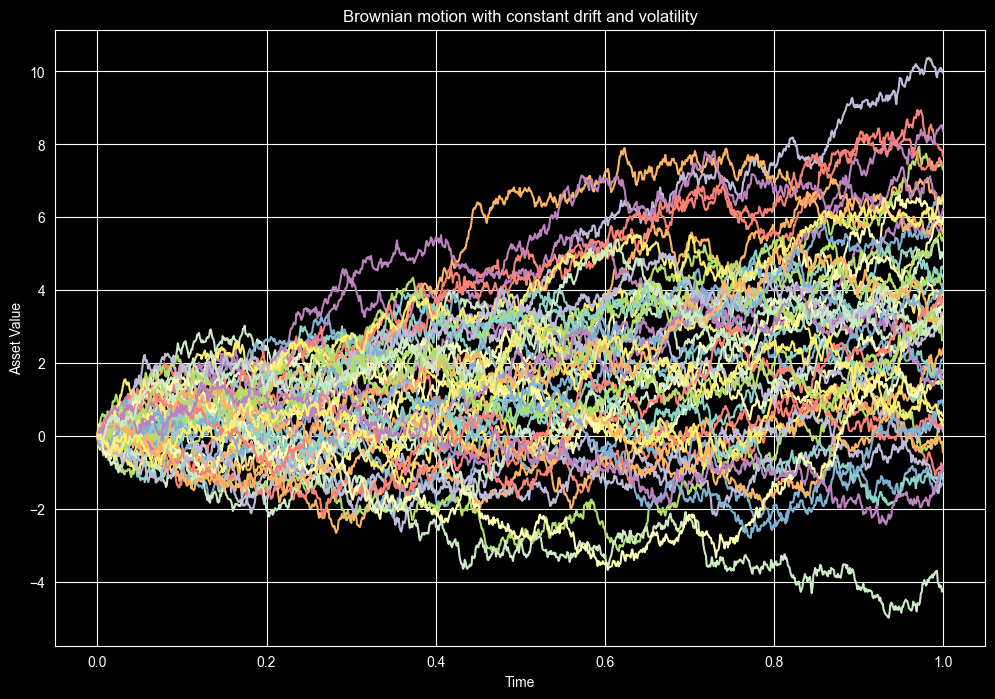

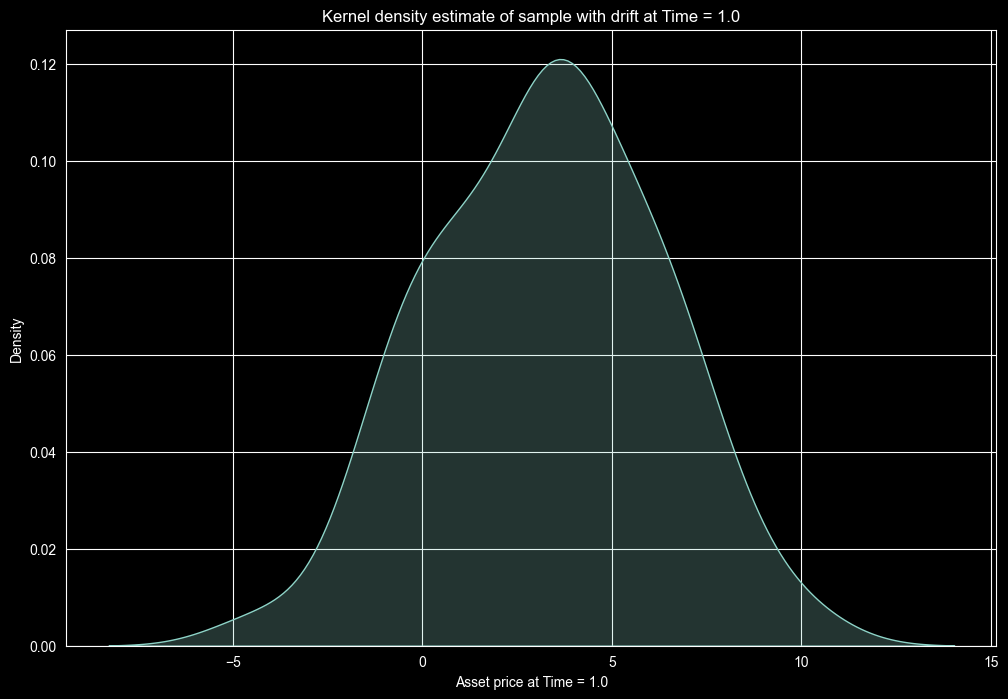

final_values_drift    3.231459
dtype: float64 final_values_drift    2.966668
dtype: float64


In [5]:
plot_drift_brownian(paths=50, points=1000, drift=4, volatility=3)

As shown above, the mean and standard deviation at Time=1 is "close" to the drift and volatility that we have chosen for this simulation.

We may even extend our coordinate system to three dimensions to construct the 3D standard Brownian motion. To do this, we write the recursive relations:

$W_x(t_{n+1})=W_x(t_n)+X_{n+1}^{x}\sqrt{t_{n+1}-t_n}$

$W_y(t_{n+1})=W_y(t_n)+X_{n+1}^{y}\sqrt{t_{n+1}-t_n}$

$W_z(t_{n+1})=W_z(t_n)+X_{n+1}^{z}\sqrt{t_{n+1}-t_n}$

where every $X_{n}^{x},X_{n}^{y},X_{n}^{z}$ are normally distributed samples with mean zero and variance one. And we code this as follows.


In [6]:
def plot_3d_std_bm(points):
    """
    Simulates 3D standard Brownian motion with a single path.

    Parameters
    ----------
    points: int
        The number of points for the path.
    """

    # Assume no drift (mu=0) and variance one.
    mu, sigma = 0.0, 1.0

    # For the purpose of this project we shall choose the time t in [0,1], and for the increments to be of equal length.
    dt = 1/points
    data = []

    # Recursive relation
    dw = rng.normal(0, sigma * np.sqrt(dt), (3, points))
    data = np.cumsum(dw, axis=1).T  # shape (points, 3)

    data = np.array(data)

    # Now to plot the standard Brownian motion.
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection='3d')
    ax.plot3D(data[:, 0], data[:, 1], data[:, 2], linewidth=0.5)
    ax.plot3D(data[0, 0], data[0, 1], data[0, 2], marker='o', color='red')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('3D standard Brownian motion')
    plt.show()

Now we shall run the code with 1000 points.

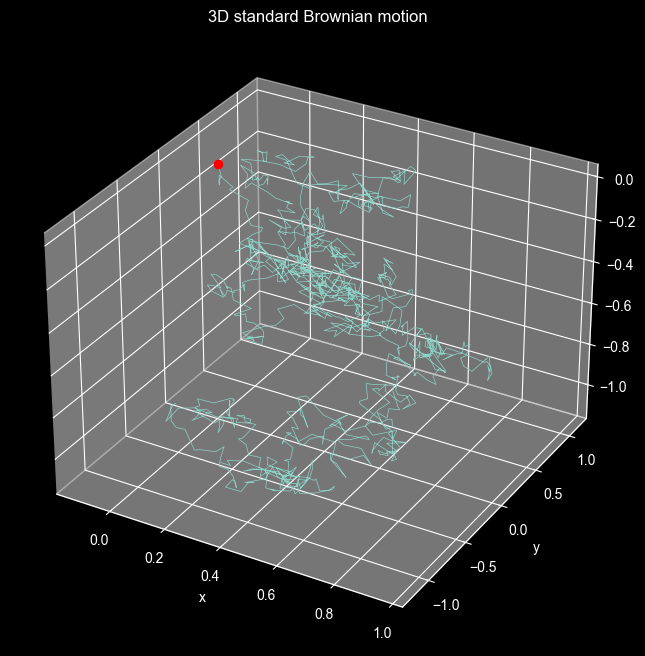

In [7]:
plot_3d_std_bm(points=1000)

## Section 3: Geometric Brownian Motion
One standard asset-price model used in the Black-Scholes-Merton option-pricing formula is the geometric Brownian motion. Let $\alpha$ and $\sigma > 0$ be real constants, then we define the geometric Brownian motion as: $S(t)=S(0) \mathrm{exp} \{ \sigma W(t) + (\alpha - \frac{1}{2} \sigma^2)t \}$. We may let $\beta = \alpha - \frac{1}{2} \sigma^2$, so that $S(t)=S(0) \mathrm{exp} \{ \sigma W(t) + \beta t \}$. If we take log of this, we shall get $\log(S(t)) - \log(S(0)) = \sigma W(t) + \beta t$.

We know from Section 1 that for standard Brownian motion, $W(t_{n+1}) - W(t_n) = X_{n+1}\sqrt{t_{n+1}-t_n}$. Hence, we may calculate the log returns as: $\log(S(t_{n+1})) - \log(S(t_n)) = \sigma X_{n+1} \sqrt{t_{n+1}-t_n} + \beta (t_{n+1}-t_n)$.

And we may implement this into code.

In [8]:
def plot_gbm(annual_trading_days, initial_stock_price, volatility, alpha):
    """
    Simulates geometric Brownian motion with a single path.

    Parameters
    ----------
    annual_trading_days: int
        The amount of trading days in a year.
    initial_stock_price: float
        The stock price at S(0).
    volatility: float
        The volatility of the process.
    alpha: float
        The real-world drift.
    """

    N = annual_trading_days
    dt = 1 / (N - 1)                        # so final time = exactly 1.0
    beta = alpha - 0.5 * volatility**2

    # Draw N-1 standard normal increments (one per step)
    X = rng.normal(0, 1, N - 1)            # shape (N-1,)

    # Log-returns
    log_returns = volatility * X * np.sqrt(dt) + beta * dt   # shape (N-1,)

    # Cumulative sum gives log(S(t_n)/S(0))
    log_path = np.concatenate([[0], np.cumsum(log_returns)])  # shape (N,)

    S = initial_stock_price * np.exp(log_path)
    t = np.linspace(0, 1, N)

    plt.figure(figsize=(12, 5))
    plt.plot(t, S, linewidth=0.8)
    plt.xlabel("Time (years)")
    plt.ylabel("Stock price (IDR)")
    plt.title("Geometric Brownian Motion")
    plt.show()

We shall now execute this function to run a simulation of stock prices over the trading days in a year, which in this example shall be 252 days, with the initial price $S(0)$ being 100 IDR, volatility $\sigma=0.2$, and $\alpha=0.1$.

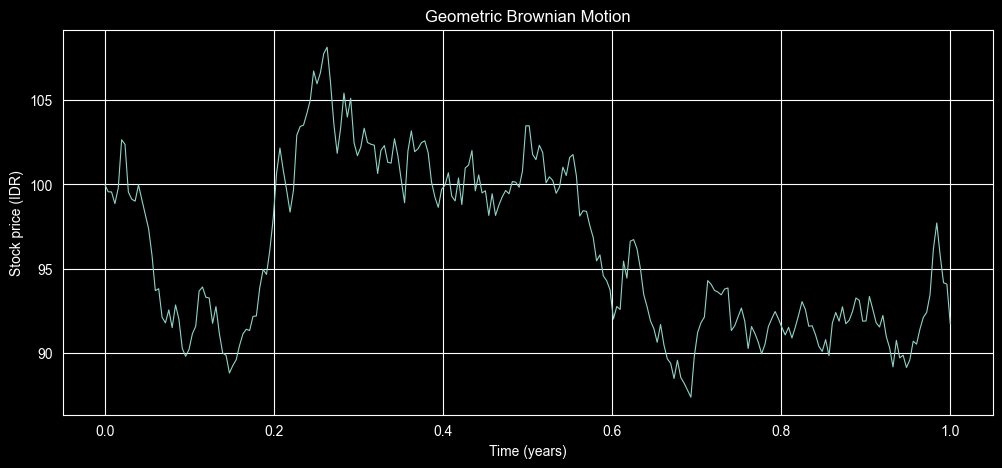

In [9]:
plot_gbm(annual_trading_days=252, initial_stock_price=100, volatility=0.2, alpha=0.1)

We may extend this to multiple paths much like in Sections 1 and 2:

In [10]:
def simulate_gbm_paths(paths, annual_trading_days, initial_stock_price, volatility, alpha):
    """
    Simulates multiple paths of geometric Brownian motion.

    Parameters
    ----------
    paths: int
        Number of paths.
    annual_trading_days: int
        The amount of trading days in a year.
    initial_stock_price: float
        The stock price at S(0).
    volatility: float
        The volatility of the process.
    alpha: float
        The real-world drift.
    """

    # Parameters
    k = paths
    N = annual_trading_days
    S0 = initial_stock_price
    dt = 1 / (N - 1)
    beta = alpha - 0.5 * volatility**2

    # The log returns
    X = rng.normal(0, 1, (k, N - 1))
    log_returns = volatility * X * np.sqrt(dt) + beta * dt

    # Prepend a column of zeros so each path starts at log(S0/S0) = 0
    zeros = np.zeros((k, 1))
    log_paths = np.concatenate([zeros, np.cumsum(log_returns, axis=1)], axis=1)

    # Take exponential
    S = S0 * np.exp(log_paths)
    t = np.linspace(0, 1, N)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t, S.T, linewidth=0.3, alpha=0.4)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Stock price (IDR)")
    ax.set_title("GBM Monte-Carlo simulation")
    plt.show()

    # Terminal prices are just the last column
    terminal = S[:, -1]
    print(f"Mean terminal price : {terminal.mean():.4f}")
    print(f"Std  terminal price : {terminal.std():.4f}")

In financial mathematics, running many simulations of a stochastic process is a method of option-pricing, such a method is understood to be a Monte-Carlo simulation. Hence in the following example, we shall do a Monte-Carlo simulation with 500 paths of geometric Brownian motion to compute the real-world terminal price.

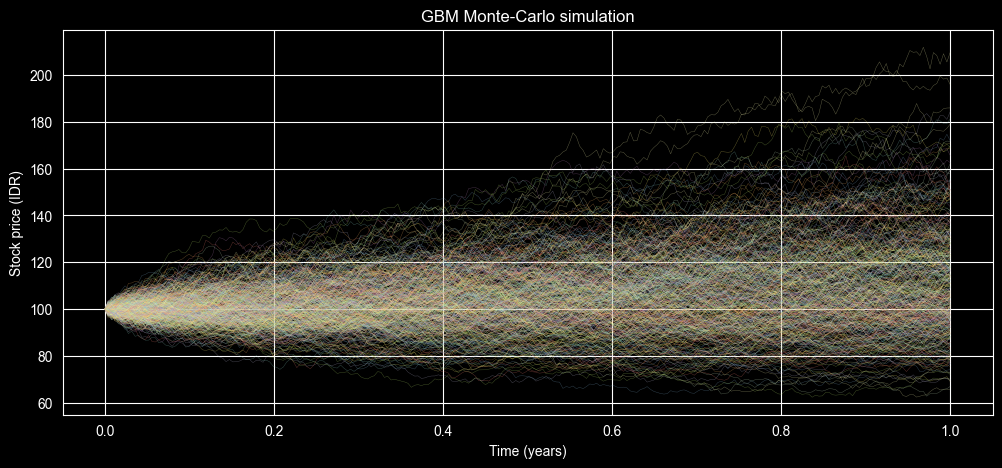

Mean terminal price : 111.4012
Std  terminal price : 22.2835


In [11]:
simulate_gbm_paths(paths=500, annual_trading_days=252, initial_stock_price=100, volatility=0.2, alpha=0.1)

The issue with the above is that it assumes real-world drift $\alpha$, which is the stock's expected return. This makes it an arbitrage-able price. For option-pricing, we must simulate under the risk-neutral measure, where the drift is replaced by some risk-free rate $r$. Then the discount factor $\mathrm{exp} (-rT)$, where $T$ is the time to maturity, gives today's price. To find a risk-neutral measure, we have to make use of the Radon-Nikodym Theorem and Girsanov's Theorem, but these are beyond the scope of this notebook, which is intended to be about Brownian motion.

Regardless, the following code is provided as an example of pricing a European call option. This function returns the Monte-Carlo estimate of the call price and the Black-Scholes closed form price.

In [12]:
def price_european_call(paths, annual_trading_days, initial_stock_price, volatility, strike, risk_free_rate, T):
    """
    Uses geometric Brownian motion to do Monte-Carlo simulations for estimation of call price and Black-Scholes closed form price.

    Parameters
    ----------
    paths: int
        Number of paths.
    annual_trading_days: int
        The amount of trading days in a year.
    initial_stock_price: float
        The stock price at S(0).
    volatility: float
        The volatility of the process.
    strike: float
        The strike price.
    risk_free_rate: float
        The risk-free rate.
    T: float
        The terminal time.
    """

    # Parameters
    S0, K, r, sigma = initial_stock_price, strike, risk_free_rate, volatility
    dt = T / (annual_trading_days - 1)

    # Under the risk-neutral measure the drift is r, not the real-world alpha.
    beta = r - 0.5 * sigma**2

    X = rng.normal(0, 1, (paths, annual_trading_days - 1))
    log_returns = sigma * X * np.sqrt(dt) + beta * dt
    log_paths = np.concatenate([np.zeros((paths, 1)), np.cumsum(log_returns, axis=1)], axis=1)
    S = S0 * np.exp(log_paths)

    # Payoff and discounted price
    S_T = S[:, -1]
    payoffs = np.maximum(S_T - K, 0.0)
    discount = np.exp(-r * T)
    mc_price = discount * payoffs.mean()
    mc_stderr = discount * payoffs.std() / np.sqrt(paths)

    # Black-Scholes closed form
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    bs_price = S0 * norm.cdf(d1) - K * discount * norm.cdf(d2)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(S_T, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
    axes[0].axvline(K, color='red', linestyle='--', linewidth=1.5,
                    label=f'Strike K = {K}')
    axes[0].set_xlabel('Terminal stock price S(T)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of terminal stock prices')
    axes[0].legend()

    itm_pct = (payoffs > 0).mean() * 100
    axes[1].hist(payoffs[payoffs > 0], bins=60,
                 color='seagreen', alpha=0.7, edgecolor='none')
    axes[1].set_xlabel('Payoff  max(S(T) − K, 0)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'In-the-money payoffs  ({itm_pct:.1f}% of paths)')

    plt.suptitle('Monte-Carlo European Call: Risk-Neutral Simulation', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"Monte Carlo price  : {mc_price:.4f}  (± {mc_stderr:.4f} std error)")
    print(f"Black-Scholes price: {bs_price:.4f}")
    print(f"Difference         : {abs(mc_price - bs_price):.4f}")

    return mc_price, bs_price

We shall now simulate 10 000 paths for 252 annual trading days with initial price 100 IDR, volatility 0.2, the strike being 105 IDR, the risk-free rate being 0.05 and time to maturity $T = 1$ year.

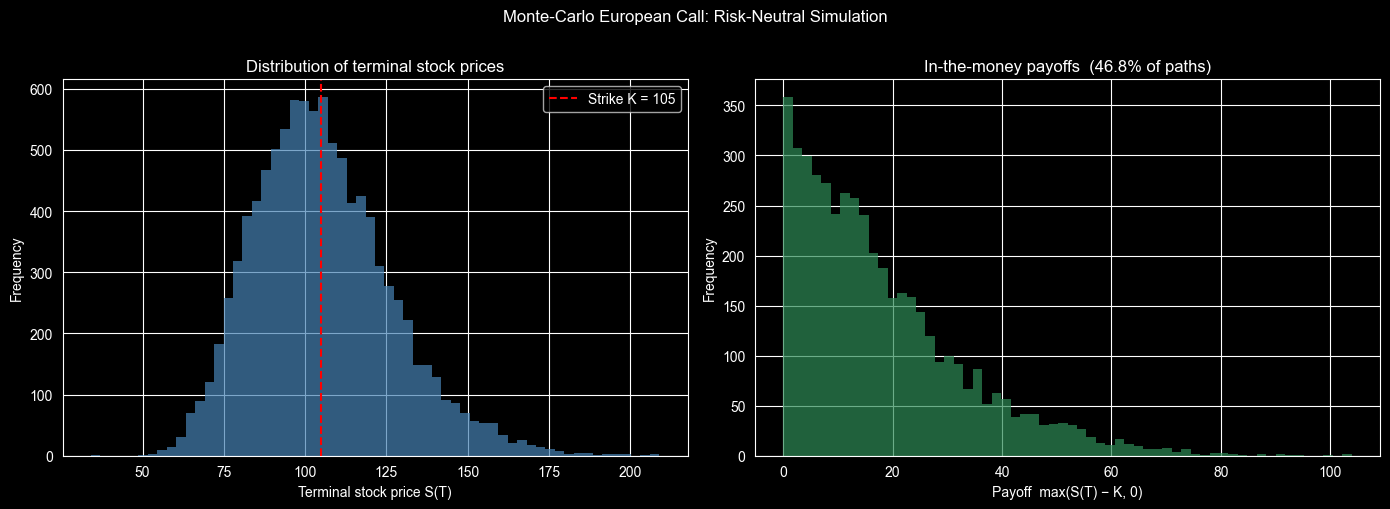

Monte Carlo price  : 8.1215  (± 0.1327 std error)
Black-Scholes price: 8.0214
Difference         : 0.1002


(np.float64(8.121510180778923), np.float64(8.021352235143176))

In [13]:
price_european_call(
    paths=10_000,
    annual_trading_days=252,
    initial_stock_price=100,
    volatility=0.2,
    strike=105,        # slightly out of the money
    risk_free_rate=0.05,
    T=1.0)

## Section 4: An application of Geometric Brownian Motion using BBCA.JK historical data
We shall now pull historical data of IDX stock from PT Bank Central Asia Tbk (BBCA.JK) to compute the log returns. Then from the log returns, we calculate their sample mean and standard deviation to calibrate the geometric Brownian motion parameters.

Recall that $S(t)=S(0) \mathrm{exp} \{ \sigma W(t) + \beta t \}$, where $\beta = \alpha - \frac{1}{2} \sigma^2$. Note that since $W(t)$ is normally distributed:

$\mathbb{E} S(t) = S(0) e^{\beta t} \int_{\Omega} \mathrm{exp} \{ \sigma W(t) \} \, d\mathbb{P} = \frac{S(0) e^{\beta t}}{\sqrt{2 \pi t}} \int_{\mathbb{R}} e^{- \frac{(w - \sigma t)^2}{2t} + \frac{1}{2} \sigma^2 t} \, dw = \frac{S(0) e^{\alpha t}}{\sqrt{2 \pi t}} \int_{\mathbb{R}} e^{- \frac{(w - \sigma t)^2}{2t}} \, dw = S(0) e^{\alpha t}$.

So that if we take $\log$ of the expectation, we obtain $\log (\mathbb{E} S(t)) = \log(S(t)) + \alpha t$.

However, if we take expectation of the $\log$, we obtain $\mathbb{E} [\log(S(t))] = \mathbb{E} [\log(S(0)) + \sigma W(t) + \beta t] = \log(S(0)) + \beta t$.

Indeed, $\log$ is concave, hence we get the Jensen gap of $- \frac{1}{2} \sigma^2 t$, which we call the Ito correction. This means that the sample mean estimates $\beta$, not $\alpha$.

In [14]:
# [Parameters]
TICKER        = "BBCA.JK"
TRADING_DAYS  = 252

# [Here we try to download the adjusted closing prices]
# auto_adjust=True uses dividend- and split-adjusted closes.
# Unadjusted prices have artificial jumps on ex-dividend dates that would inflate the estimated volatility.
try:
    raw = yf.download(TICKER, period="2y", auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError(f"No data returned for {TICKER}")
except Exception as e:
    raise RuntimeError(f"Data download failed: {e}")

# Extract data, reduce dimensions, and remove any NaN or None
prices = raw["Close"].squeeze().dropna()

# [Daily log-returns]
# r(t_n) = log(S(t_n) / S(t_{n-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# [Calibration]
# The GBM from Section 4 implies daily log-returns are normally distributed:
#
#   log(S(t_n) / S(t_{n-1}) ~ N(beta * dt,  sigma^2 * dt)
#
# where beta = alpha - 0.5 * sigma**2. Matching moments to the sample:

mu_daily    = log_returns.mean() # sample mean  of daily log-return
sigma_daily = log_returns.std() # sample std   of daily log-return

sigma = sigma_daily * np.sqrt(TRADING_DAYS) # annualised volatility
beta  = mu_daily    * TRADING_DAYS # annualised log-drift

# alpha requires an Ito correction. The sample mean estimates beta, not alpha,
# because E[log S(t)] = log S(0) + beta*t  does not equal  log E[S(t)] = log S(0) + alpha*t.
# To recover alpha:  alpha = beta + 0.5 * sigma^2
alpha = beta + 0.5 * sigma**2

print(f"{'Ticker':<28}: {TICKER}")
print(f"{'Period':<28}: {prices.index[0].date()}  →  {prices.index[-1].date()}")
print(f"{'Observations':<28}: {len(log_returns)} trading days")
print("─" * 50)
print(f"{'Daily μ  (log-return)':<28}: {mu_daily:.6f}")
print(f"{'Daily σ  (log-return)':<28}: {sigma_daily:.6f}")
print("─" * 50)
print(f"{'Annualised σ':<28}: {sigma:.4f}   ({sigma * 100:.2f} %)")
print(f"{'Annualised β  (= α − ½σ²)':<28}: {beta:.4f}   ({beta * 100:.2f} %)")
print(f"{'Annualised α  (expected return)':<28}: {alpha:.4f}   ({alpha * 100:.2f} %)")

Ticker                      : BBCA.JK
Period                      : 2024-06-10  →  2026-06-08
Observations                : 476 trading days
──────────────────────────────────────────────────
Daily μ  (log-return)       : -0.001240
Daily σ  (log-return)       : 0.017684
──────────────────────────────────────────────────
Annualised σ                : 0.2807   (28.07 %)
Annualised β  (= α − ½σ²)   : -0.3125   (-31.25 %)
Annualised α  (expected return): -0.2731   (-27.31 %)


We now plot the following:

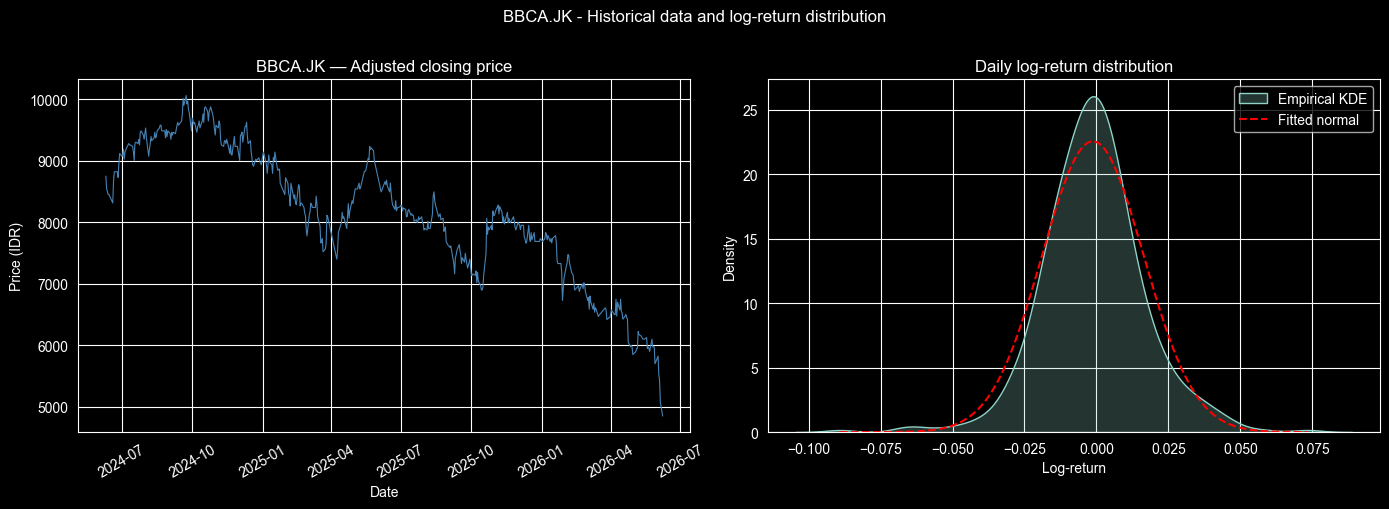

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price history
axes[0].plot(prices.index, prices.values, linewidth=0.8, color='steelblue')
axes[0].set_title(f"{TICKER} — Adjusted closing price")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price (IDR)")
axes[0].tick_params(axis='x', rotation=30)

# Right: empirical log-return distribution vs. fitted normal
# This is a visual check of the normality assumption underlying GBM.
lr_df = pd.DataFrame({'log_return': log_returns.values})
sns.kdeplot(data=lr_df, x='log_return', fill=True, ax=axes[1], label='Empirical KDE')

x = np.linspace(log_returns.min(), log_returns.max(), 300)
fitted_normal = norm.pdf(x, loc=mu_daily, scale=sigma_daily)
axes[1].plot(x, fitted_normal, color='red', linestyle='--', linewidth=1.5, label='Fitted normal')

axes[1].set_title("Daily log-return distribution")
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle(f"{TICKER} - Historical data and log-return distribution", y=1.01)
plt.tight_layout()
plt.show()

We may now overlay the calibrated geometric Brownian motion on the actual price history.

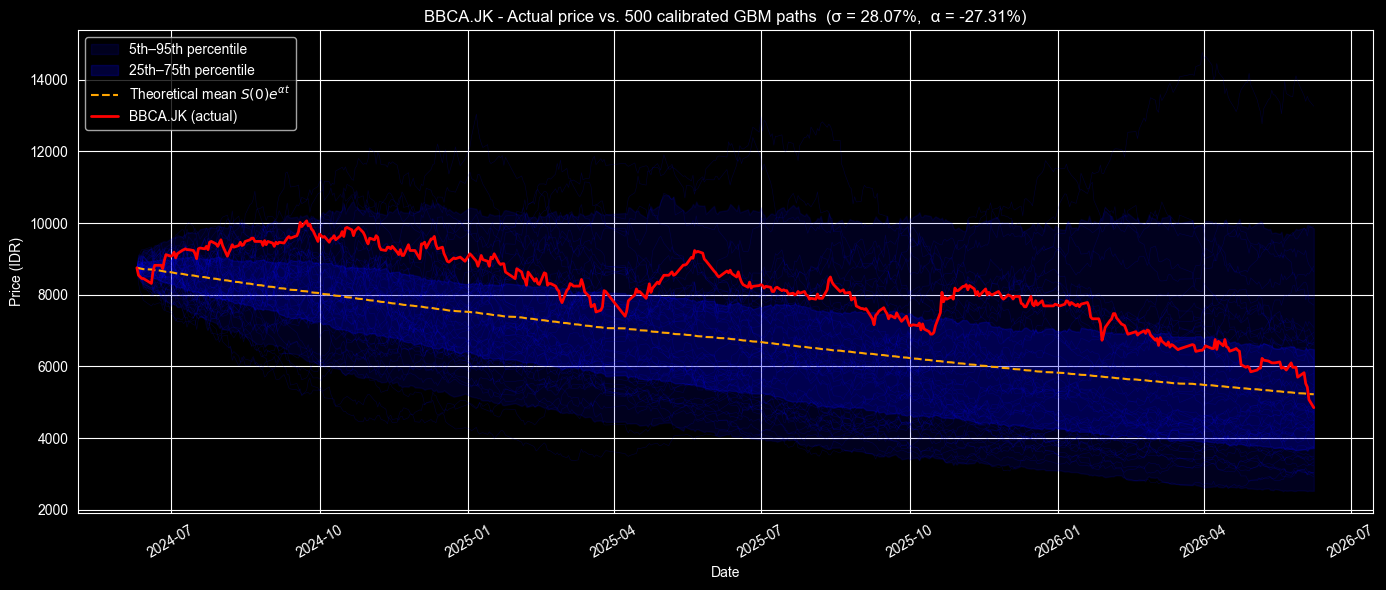

In [16]:
def overlay_gbm_paths(prices, sigma, alpha, trading_days, sim_paths=500, plot_paths=50):
    """
    Overlays calibrated GBM simulations on the actual price history.

    Parameters
    ----------
    prices: pd.Series
        Historical adjusted closing prices with a DatetimeIndex.
    sigma: float
        Annualised volatility from calibration.
    alpha: float
        Annualised expected return from calibration.
    trading_days: int
        The amount of trading days.
    sim_paths: int
        Total paths to simulate; used for percentile bands.
    plot_paths: int
        Number of individual paths to draw (must be <= sim_paths).
    """

    plot_paths = min(plot_paths, sim_paths)

    N    = len(prices)
    S0   = float(prices.iloc[0])
    dt   = 1.0 / trading_days
    beta = alpha - 0.5 * sigma**2

    # Simulate all paths from the same starting price S0
    X           = rng.normal(0, 1, (sim_paths, N - 1))
    sim_log_ret = sigma * X * np.sqrt(dt) + beta * dt
    log_paths   = np.concatenate([np.zeros((sim_paths, 1)),
                                   np.cumsum(sim_log_ret, axis=1)], axis=1)
    S = S0 * np.exp(log_paths)

    dates = prices.index
    t     = np.arange(N) / trading_days            # time in years per step

    # Percentile bands derived from all sim_paths
    p05 = np.percentile(S,  5, axis=0)
    p25 = np.percentile(S, 25, axis=0)
    p75 = np.percentile(S, 75, axis=0)
    p95 = np.percentile(S, 95, axis=0)

    # Theoretical mean E[S(t)] = S0 * exp(alpha * t)
    mean_path = S0 * np.exp(alpha * t)

    fig, ax = plt.subplots(figsize=(14, 6))

    # Individual simulated paths (subset for visual clarity)
    for i in range(plot_paths):
        ax.plot(dates, S[i], linewidth=0.4, alpha=0.2, color='blue')

    # Nested percentile bands
    ax.fill_between(dates, p05, p95, alpha=0.12, color='blue',
                    label='5th–95th percentile')
    ax.fill_between(dates, p25, p75, alpha=0.22, color='blue',
                    label='25th–75th percentile')

    # Theoretical mean - drawn before the actual path so it sits beneath it
    ax.plot(dates, mean_path, linewidth=1.5, color='orange',
            linestyle='--', label=r'Theoretical mean $S(0) e^{\alpha t}$')

    # Actual price - drawn last so it sits on top of everything
    ax.plot(dates, prices.values, linewidth=2.0, color='red',
            label=f'{TICKER} (actual)', zorder=5)

    ax.set_title(
        f"{TICKER} - Actual price vs. {sim_paths} calibrated GBM paths  "
        f"(σ = {sigma:.2%},  α = {alpha:.2%})"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (IDR)")
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

overlay_gbm_paths(prices, sigma, alpha, trading_days=TRADING_DAYS, sim_paths=500, plot_paths=50)

### Interpretation
Indeed, geometric Brownian motion does not capture the actual historical price exactly because it assumes constant drift and volatility. This is addressed by the Heston model, which takes into account the stochastic volatility of a derivative.

Section 5 will lean more theoretical.

## Section 5: First Passage Time and Max of Brownian Motion to Date

**Definition 2.** Let $m$ be a real number. We define the first passage time to barrier $m$ as $\tau_m = \mathrm{min} \{t \geq 0 \mid W(t)=m \}$. This is the first time a Brownian motion reaches the barrier m. If the Brownian motion never reaches m, then we set $\tau_m = \infty$.

We shall now fix a positive level $m$ and a positive time $t$. What happens when Brownian motion reaches level $m$ prior to time $t$, but is at a level $w$ below $m$ at time $t$? If we draw a reflected path of the Brownian motion after $\tau_m$, we shall see that due to the symmetry of Brownian motion, we may obtain the reflection equality: $\mathbb{P}\{\tau_m \leq t, W(t) \leq m\} = \mathbb{P}\{W(t) \geq 2m-w\}, w \leq m, m > 0$.

To see that this is true, we may code the following.

In [17]:
def plot_ref_bm(points, drift, volatility, barrier):
    """
    Graphically displays the reflection principle of a path of Brownian motion with drift and volatility given a barrier.

    Parameters
    ----------
    points: int
        Number of points to plot.
    drift: float
        The drift of the Brownian motion.
    volatility: float
        The volatility of the Brownian motion.
    barrier: float
        The barrier upon which the first passage time is determined.
    """

    dt = 1 / points
    t_axis = np.linspace(0.0, 1.0, points + 1)

    # Sample all increments at once and prepend W(0) = 0
    dw = rng.normal(drift * dt, volatility * np.sqrt(dt), points)
    path = np.concatenate([[0.0], np.cumsum(dw)])

    # Reflected path mirrors original only after the first barrier crossing
    reflected = path.copy()
    hit_mask = path >= barrier
    hit_barrier = hit_mask.any()

    if hit_barrier:
        hit_idx = int(np.argmax(hit_mask)) # index of first crossing
        reflected[hit_idx:] = 2.0 * barrier - path[hit_idx:]

    # Plot
    plt.figure(figsize=(12, 8))
    plt.plot(t_axis, path, label='Original Brownian motion',
             linewidth=1, color='blue', alpha=0.5)

    if hit_barrier:
        plt.plot(t_axis, reflected, label='Reflected path',
                 linewidth=1.5, color='red', linestyle='--')
        plt.axhline(y=barrier, color='green', linestyle=':',
                    linewidth=2, label=f'Barrier ({barrier})')

    plt.xlabel('Time')
    plt.ylabel('Process value')
    plt.ylim([min(path.min(), reflected.min()) - 10,
              max(path.max(), reflected.max()) + 10])
    plt.title('Brownian motion with reflection principle')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

The reflected path of Brownian motion can be written as $W_{ref}(t) = 2m - W(t)$. We now execute an example wherein we have 1000 points, drift 10, volatility 5 and barrier 3.

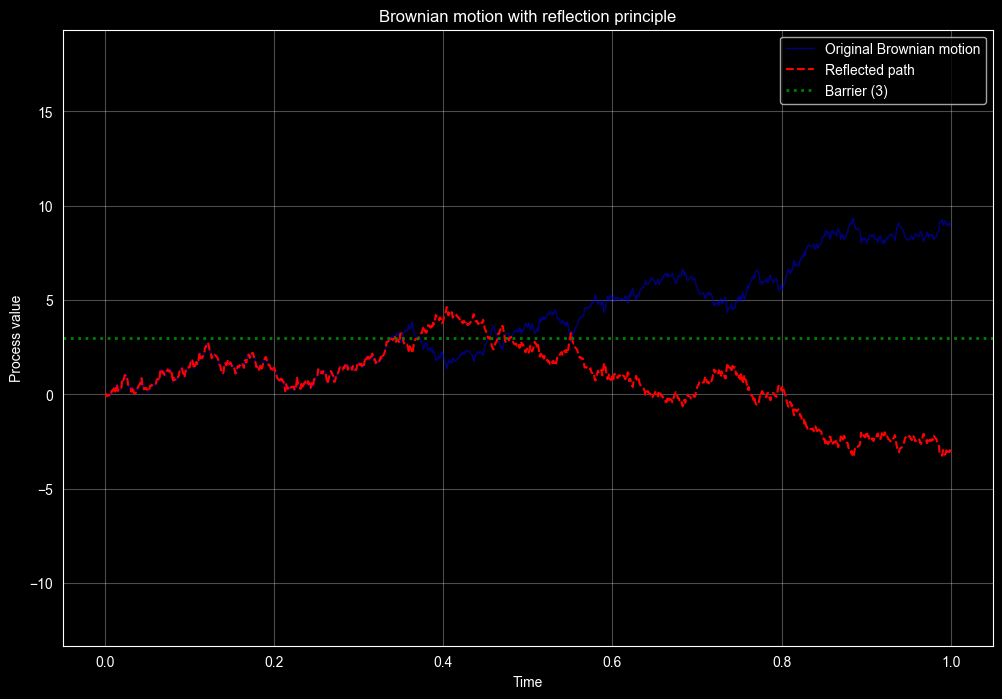

In [18]:
plot_ref_bm(points=1000, drift=10, volatility=5, barrier=3)

Hence, we may now obtain the distribution for the first passage time $\tau_m$.

**Theorem 3.** For all nonzero $m$, the random variable $\tau_m$ has cumulative distribution function:

$\mathbb{P}\{\tau_m \leq t\} = \frac{2}{\sqrt{2 \pi t}} \int_{|m|}^{\infty} e^{-\frac{x^2}{2t}} \, dx, t \geq 0$.

**Proof.** First, we consider the case wherein $m > 0$. If we let $w = m$, then $\mathbb{P}\{\tau_m \leq t, W(t) \leq m\} = \mathbb{P}\{W(t) \geq m\}$. On the other hand, if $W(t) \geq m$, then $\tau_m \leq t$. Hence, $\mathbb{P}\{\tau_m \leq t, W(t) \geq m\} = \mathbb{P}\{W(t) \geq m\}$. If we add these equalities, then we obtain the cumulative distribution function for $\tau_m$:

$\mathbb{P}\{\tau_m \leq t\} = \mathbb{P}\{\tau_m \leq t, W(t) \leq m\} + \mathbb{P}\{\tau_m \leq t, W(t) \geq m\} = 2 \mathbb{P}\{W(t) \geq m\} = \frac{2}{\sqrt{2 \pi t}} \int_{m}^{\infty} e^{-\frac{x^2}{2t}} \, dx$.

Where the last equality holds because Brownian motion $W(t)$ is a normally distributed random variable with mean 0 and variance $t$. If $m < 0$, then $\tau_m$ and $\tau_{|m|}$ have the same distribution due to symmetry. Hence, we have the equality stated in **Theorem 3**.

We now introduce another stochastic process used for pricing barrier options:

**Definition 4.** The maximum to date for Brownian motion is $M(t) = \max_{s \in [0,t]} W(s)$.

In code, this looks like the following.

In [19]:
def plot_mtd_bm(points, drift, volatility):
    """
    Simulates max of Brownian motion to date with a single path.

    Parameters
    ----------
    points: int
        Number of points to plot.
    drift: float
        The drift of the Brownian motion.
    volatility: float
        The volatility of the Brownian motion.
    """

    dt = 1 / points
    t_axis = np.arange(1, points + 1) * dt

    # Brownian motion with drift
    dw = rng.normal(drift * dt, volatility * np.sqrt(dt), points)
    path = np.cumsum(dw)

    # $M(t) = \max_{s \in [0,t]} W(s)$
    mtd = np.maximum.accumulate(path)          # applied to 1D path only

    plt.figure(figsize=(12, 8))
    plt.plot(t_axis, mtd, linewidth=1, color='blue')
    plt.xlabel('Time')
    plt.ylabel('Stock price')
    plt.title('Max of Brownian motion to date')
    plt.show()

Here we shall simulate 1000 points, let drift be 0, and volatility 0.2. This adapted stochastic process happens to also be a submartingale.

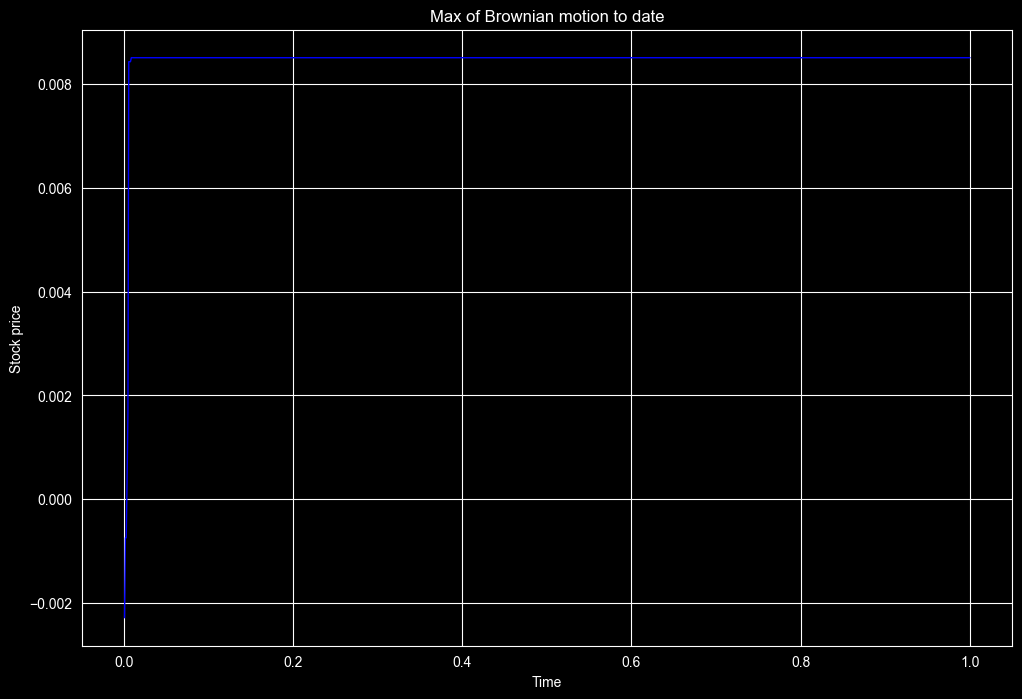

In [20]:
plot_mtd_bm(points=1000, drift=0, volatility=0.2)

From the proof of **Theorem 3**, we know that for positive $m$, we have $M(t) \geq m$ if and only if $\tau_m \leq t$. Hence, we may write the reflection equality as: $\mathbb{P}\{M(t) \geq m, W(t) \leq m\} = \mathbb{P}\{W(t) \geq 2m-w\}, w \leq m, m > 0$. This allows us to obtain the joint distribution of $M(t)$ and $W(t)$.

**Theorem 5.** For positive $t$, the joint density of $M(t)$ and $W(t)$ is:

$f_{M(t),W(t)}(m,w) = \frac{2(2m-w)}{t \sqrt{2 \pi t}} e^{- \frac{(2m-w)^2}{2t}}, w \leq m, m > 0$.

**Proof.** We know that:

$\mathbb{P}\{M(t) \geq m, W(t) \leq m\} = \int_{m}^{\infty} \int_{- \infty}^{w} f_{M(t),W(t)}(x,y) \, dy \, dx$,

and

$\mathbb{P}\{W(t) \geq 2m-w\} = \frac{1}{\sqrt{2 \pi t}} \int_{2m-w}^{\infty} e^{-\frac{z^2}{2t}} \, dz$.

Combining these two we get:

$\int_{m}^{\infty} \int_{- \infty}^{w} f_{M(t),W(t)}(x,y) \, dy \, dx = \frac{1}{\sqrt{2 \pi t}} \int_{2m-w}^{\infty} e^{-\frac{z^2}{2t}} \, dz$.

We differentiate first with respect to $m$ to obtain:

$- \int_{- \infty}^{w} f_{M(t),W(t)}(m,y) \, dy = - \frac{2}{\sqrt{2 \pi t}} e^{-\frac{(2m-w)^2}{2t}}$.

We next differentiate with respect to $w$ to see that:

$- f_{M(t),W(t)}(m,w) = - \frac{2(2m-w)}{t \sqrt{2 \pi t}} e^{- \frac{(2m-w)^2}{2t}}$.

We are done.

This leads naturally to the following corollary.

**Corollary 6.** The conditional distribution of $M(t)$ given $W(t)=w$  is:

$f_{M(t) \mid W(t)}(m \mid w) = \frac{2(2m-w)}{t} e^{- \frac{2m(m-w)}{t}}, w \leq m, m > 0$.

**Proof.** By Bayes' Theorem, the conditional density is the joint density divided by the marginal density of the conditioning random variable. Thus,

$f_{M(t) \mid W(t)}(m \mid w) = \frac{f_{M(t),W(t)}(m,w)}{f_{W(t)}(w)} = \frac{2(2m-w)}{t \sqrt{2 \pi t}} \sqrt{2 \pi t} e^{- \frac{(2m-w)^2}{2t} + \frac{w^2}{2t}} = \frac{2(2m-w)}{t} e^{- \frac{2m(m-w)}{t}}$

We can code this to visualise.

In [21]:
def conditional_pdf(m, w, t):
    """
    Calculates the conditional PDF of M(t) given W(t)=w, i.e., f(m|w) = (2(2m-w)/t) * exp(-2m(m-w)/t)
    """
    return (2 * (2 * m - w) / t) * np.exp(-2 * m * (m - w) / t)

def plot_2d_distribution(t, w_values, m_max=5.0):
    """
    Generates a 2D line plot for the conditional distribution given specific values of W(t) = w.
    """
    plt.figure(figsize=(10, 6))

    for w in w_values:
        # Constraint: The max to date (m) must be >= 0 AND >= W(t)
        m_min = max(0.0, w)

        # Create an array of m values from the minimum valid m up to m_max
        # Adding a tiny offset to avoid evaluating exactly at m=0 if w<0
        m = np.linspace(m_min + 0.001, m_max, 500)

        # Calculate density
        pdf = conditional_pdf(m, w, t)

        plt.plot(m, pdf, label=f'$W(t) = {w}$')

    plt.title(f'Conditional Distribution of $M(t)$ given $W(t)$, $t={t}$')
    plt.xlabel('Maximum value $m$')
    plt.ylabel('Density $f_{M(t)|W(t)}(m|w)$')
    plt.legend()
    plt.grid(alpha=0.4)
    plt.show()

def plot_3d_surface(t, m_max=5.0, w_min=-3.0, w_max=3.0):
    """
    Generates a 3D surface plot mapping the density across combinations of m and w.
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create grid for w and m
    w_vals = np.linspace(w_min, w_max, 100)
    m_vals = np.linspace(0.001, m_max, 100)
    W, M = np.meshgrid(w_vals, m_vals)

    # Initialize the Z (PDF) array with zeros
    Z = np.zeros_like(W)

    # Apply the mathematical constraints: m >= 0 and m >= w
    valid_mask = (M >= 0) & (M >= W)

    # Calculate PDF only where the constraints are met
    Z[valid_mask] = conditional_pdf(M[valid_mask], W[valid_mask], t)
    Z[~valid_mask] = np.nan # Hide invalid regions

    surf = ax.plot_surface(M, W, Z, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title(f'3D Surface of $f_{{M(t)|W(t)}}(m|w)$ at $t={t}$')
    ax.set_xlabel('Maximum $m$')
    ax.set_ylabel('Terminal Value $w$')
    ax.set_zlabel('Density')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Probability Density')
    plt.show()

Let us fix $t=1$, then:

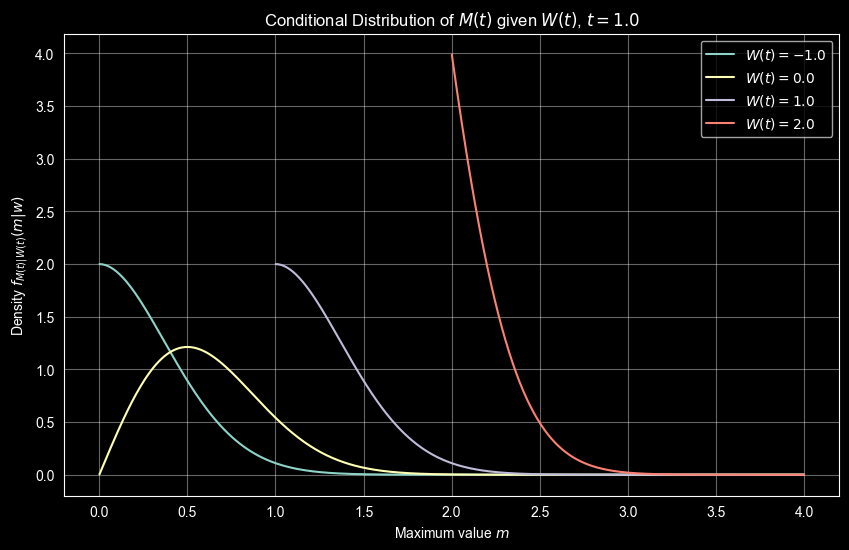

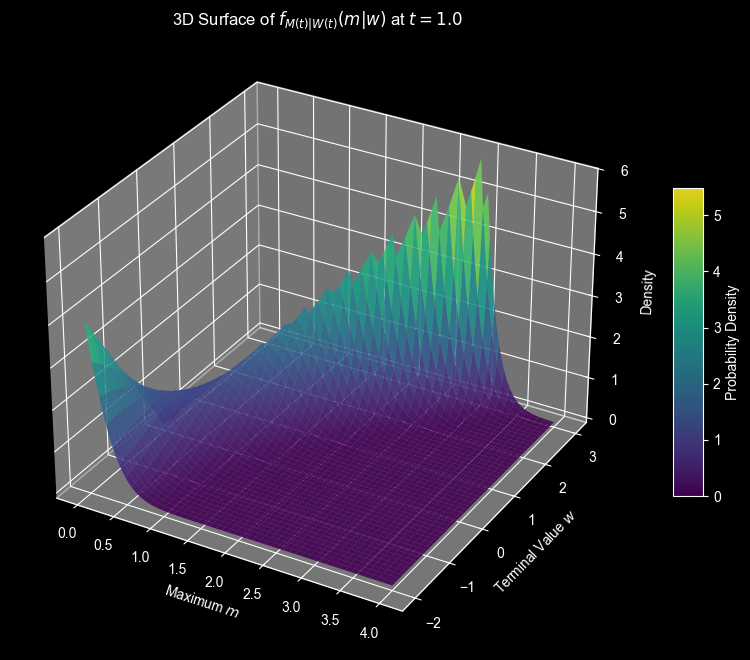

In [22]:
# Plot 2D slices for w = -1, 0, 1, 2
plot_2d_distribution(t=1.0, w_values=[-1.0, 0.0, 1.0, 2.0], m_max=4.0)

# Plot the 3D surface
plot_3d_surface(t=1.0, m_max=4.0, w_min=-2.0, w_max=3.0)

## Conclusions

When simulating Brownian motion to price exotic options, quantitative analysts often simulate the value of the Brownian motion at some time $T > 0$ and then simulate the maximum of the Brownian motion between times 0 and $t$. This second step often requires them to make use of the distribution of the submartingale $M(t)$ on $[0,t]$ conditioned on the value of $W(t)$ that we have obtained above in **Corollary 6**.

Hence, some natural extensions to this project would include the pricing of exotic options, the Heston model, and Girsanov's Theorem.

Stay tuned for other projects on my GitHub.